In [44]:
import openai
from pydantic import BaseModel, Field
from google.genai.types import GenerateContentConfig
from google import genai
from datetime import datetime, timezone

In [49]:
class Product(BaseModel):
    name : str
    description : str
    brand : str
    price : float
    quantity : int
    product_category : str
    created_at : datetime

class ProductResponse(BaseModel):
    products : list[Product]

class StockEvent(BaseModel):
    event_type: str = Field(description="Type of event: 'Holiday Rush', 'Good Friday' etc.'")
    product_name: str
    expected_date: datetime = Field(description=f"Date of the event after {datetime.now()}")
    quantity_change: int = Field(description="Positive for incoming, negative for outgoing")
    notes: str

class StockEventList(BaseModel):
    events: list[StockEvent]

In [46]:
prompt = "Generate 5 products for a toy store"

response_t0 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt,
    config = GenerateContentConfig(
        temperature=0.0,
        response_json_schema=ProductResponse.model_json_schema(),
        response_mime_type="application/json"
    )
)

usage_t0 = response_t0.usage_metadata
print(f"Response:\n{response_t0.text}\n")
print(f"Tokens Used: Prompt({usage_t0.prompt_token_count}) + Completion({usage_t0.candidates_token_count}) = Total({usage_t0.total_token_count})")


response_t15 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt,
    config = GenerateContentConfig(
        temperature=1.5,
        response_json_schema=ProductResponse.model_json_schema(),
        response_mime_type="application/json"
    )
)

usage_t15 = response_t15.usage_metadata
print(f"Response:\n{response_t15.text}\n")
print(f"Tokens Used: Prompt({usage_t15.prompt_token_count}) + Completion({usage_t15.candidates_token_count}) = Total({usage_t15.total_token_count})")

Response:
{"products":[{"name":"Sparkle Unicorn Plush","description":"A soft and cuddly plush unicorn with glittery horn and hooves, perfect for imaginative play.","brand":"DreamToys","price":19.99,"quantity":150,"product_category":"Stuffed Animals","created_at":"2023-10-27T10:00:00Z"},{"name":"Mega Blaster 5000 Dart Gun","description":"High-powered dart gun with foam darts, featuring rapid-fire action and long-range accuracy.","brand":"ActionZone","price":29.95,"quantity":75,"product_category":"Action Figures & Blasters","created_at":"2023-10-27T10:05:00Z"},{"name":"Rainbow Stacking Rings","description":"Classic baby toy with colorful rings of varying sizes to stack, promoting motor skills and color recognition.","brand":"BabyJoy","price":12.50,"quantity":200,"product_category":"Infant & Toddler Toys","created_at":"2023-10-27T10:10:00Z"},{"name":"Galaxy Explorer Lego Set","description":"An advanced Lego building set to construct a detailed spaceship and astronaut figures, for ages 8+.

In [50]:
prompt_text = "Generate a list of 10 future stock events for a toy store inventory. Include a mix of 'Restock' and 'Pre-order' shipments."

response_3 = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt_text,
        config=GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=StockEventList.model_json_schema(),
            temperature=0.8
        )
    )

print(response_3.text)

{"events": [{"event_type": "Restock", "product_name": "LEGO Star Wars Millennium Falcon", "expected_date": "2026-11-15T10:00:00Z", "quantity_change": 50, "notes": "Anticipating holiday rush demand for popular LEGO set."}, {"event_type": "Pre-order", "product_name": "Barbie Dreamhouse 2027 Edition", "expected_date": "2027-01-20T09:30:00Z", "quantity_change": 30, "notes": "Exclusive pre-order shipment for new Barbie Dreamhouse model."}, {"event_type": "Restock", "product_name": "Hot Wheels 50-Car Pack", "expected_date": "2026-12-01T14:00:00Z", "quantity_change": 100, "notes": "Replenishing stock for best-selling Hot Wheels multi-pack."}, {"event_type": "Pre-order", "product_name": "New Pokémon Trading Card Game Set", "expected_date": "2027-03-10T11:00:00Z", "quantity_change": 75, "notes": "Incoming shipment for highly anticipated new Pokémon TCG expansion."}, {"event_type": "Restock", "product_name": "Play-Doh Mega Pack", "expected_date": "2027-02-05T13:00:00Z", "quantity_change": 80, "n

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4116.18it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Lego Castle vs Wooden Blocks: 0.4139
Lego Castle vs Action Figure: 0.2170
Wooden Blocks vs Action Figure: 0.1597


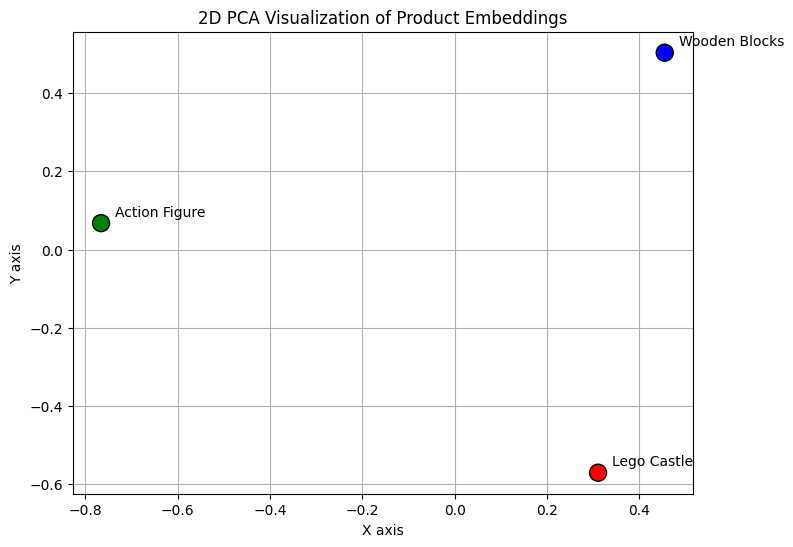

In [51]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model = SentenceTransformer('all-MiniLM-L6-v2')

products = ["Lego Castle", "Wooden Blocks", "Action Figure"]

embeddings = model.encode(products)

lego_vec = embeddings[0]
wood_vec = embeddings[1]
action_vec = embeddings[2]

def calculate_cosine_similarity(vec_a, vec_vec_b):
    dot_product = np.dot(vec_a, vec_vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_vec_b)
    return dot_product / (norm_a * norm_b)

sim_lego_wood = calculate_cosine_similarity(lego_vec, wood_vec)
sim_lego_action = calculate_cosine_similarity(lego_vec, action_vec)
sim_wood_action = calculate_cosine_similarity(wood_vec, action_vec)

print(f"Lego Castle vs Wooden Blocks: {sim_lego_wood:.4f}")
print(f"Lego Castle vs Action Figure: {sim_lego_action:.4f}")
print(f"Wooden Blocks vs Action Figure: {sim_wood_action:.4f}")


pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))

colors = ['red', 'blue', 'green']

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, s=150, edgecolors='black')

for i, product in enumerate(products):
    plt.annotate(
        product, 
        (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
        xytext=(10, 5),
        textcoords='offset points',
    )

plt.title("2D PCA Visualization of Product Embeddings")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.grid(True)
plt.show()